In [1]:
"""

----------  Sélection de 4 sujets et 188 de leurs essais ------ 

"""

import numpy as np
import matplotlib.pyplot as plt

# Lecture des donnees
nomvar=np.loadtxt("KeyboardData1.csv",delimiter=',',dtype='str',max_rows=1)[1:]
print(nomvar)
key=np.loadtxt("KeyboardData1.csv",delimiter=',',skiprows=1)

# Le tableau individus/variables et le vecteur des numeros de sujet pour chaque individu
X=key[:,1:]
y=key[:,0].astype(int) 
slist=np.unique(y)
ns=len(slist) # nombre de sujets 
print('\nIl y a ',ns, 'sujets')
ne=sum(y==2) 
print("Nombre d'essais pour chaque sujet:\n",[sum(y==l) for l in slist])
print('Il y a ',X.shape[1],'mesures pour chaque essai')

# On extrait désormais la moitié des essais de chacun, utile pour des calculs couteux : algo Lance-Willson > n^2
per=np.random.choice(ne,size=ne//2, replace=False)
select=np.tile(per,ns)+np.repeat(np.arange(ns)*ne,ne//2)
X=X[select,:]
y=y[select]
print("Nombre d'essais pour chaque sujet apres selection:\n",[sum(y==l) for l in slist])

['H.period' 'UD.period.t' 'H.t' 'UD.t.i' 'H.i' 'UD.i.e' 'H.e' 'UD.e.five'
 'H.five' 'UD.five.Shift.r' 'H.Shift.r' 'UD.Shift.r.o' 'H.o' 'UD.o.a'
 'H.a' 'UD.a.n' 'H.n' 'UD.n.l' 'H.l' 'UD.l.Return' 'H.Return']

Il y a  51 sujets
Nombre d'essais pour chaque sujet:
 [376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376, 376]
Il y a  21 mesures pour chaque essai
Nombre d'essais pour chaque sujet apres selection:
 [188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188, 188]


In [3]:
# On ne selectionne plus que quatres sujets
print("\nslist :",slist)
sujet_alea=np.random.choice(slist,4, replace=False)
print("\nsujets aléatoirs : ",sujet_alea)
mask = np.isin(y, sujet_alea)
X = X[mask]
y = y[mask]
alea_slist=np.unique(y)
nss=len(alea_slist) # nombre de sujets 
print('\nIl y a ',nss, 'sujets')
print("\nX :",X)
print("\ny :",y)



slist : [ 2  3  4  5  7  8 10 11 12 13 15 16 17 18 19 20 21 22 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 46 47 48 49 50 51 52 53 54
 55 56 57]

sujets aléatoirs :  [37 10  3 16]

Il y a  4 sujets

X : [[ 0.1066  0.3076  0.1193 ...  0.0692  0.2363  0.0874]
 [ 0.1505 -0.0461  0.1303 ...  0.0953  0.1189  0.1056]
 [ 0.1481  0.048   0.1996 ...  0.1172  0.1128  0.1051]
 ...
 [ 0.0847 -0.0049  0.0821 ...  0.0952  0.0972  0.1045]
 [ 0.1066 -0.0291  0.0926 ...  0.1242  0.1075  0.1021]
 [ 0.1174  0.0305  0.0855 ...  0.1053  0.112   0.1071]]

y : [ 3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3 

E_k : [0.34351266 0.22289054 0.06276306 0.04090942 0.03540613 0.03315083
 0.02879377 0.02674701 0.02549007 0.0242534  0.02296267 0.02027407
 0.01868845 0.01770718 0.01429386 0.01337892 0.01264181 0.01085095
 0.01003175 0.00791683 0.00733664]
0.705481811720176


Text(0, 0.5, 'C2')

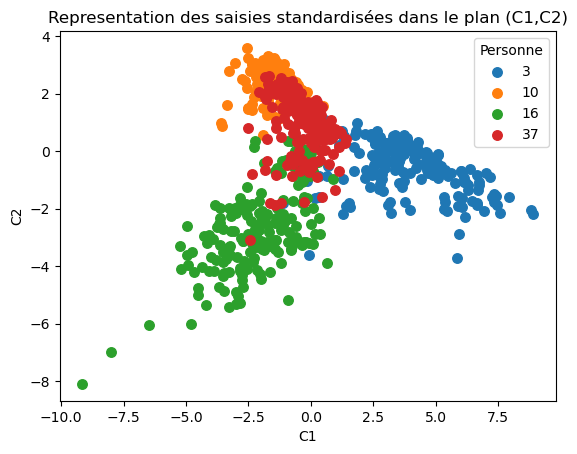

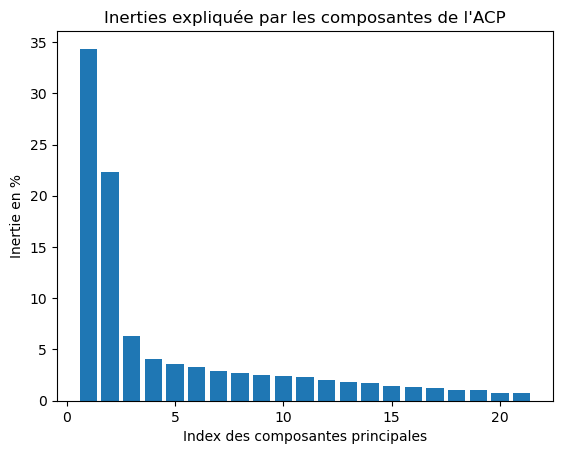

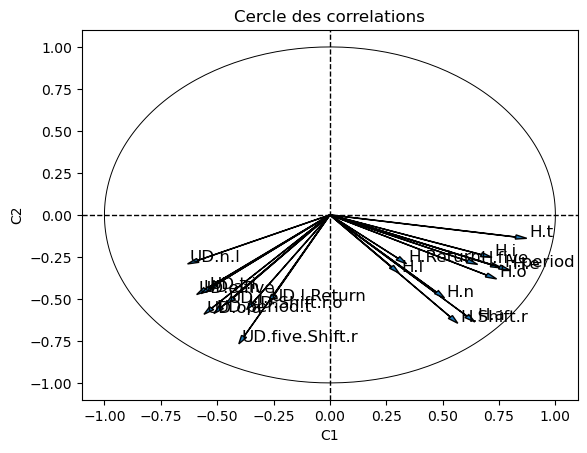

In [5]:
"""
ACP
"""

# Fonction de standardisation
def stdise(X):
  """Routine de standardisation
     On pourrrait utiliser scikitlearn: Exemple:
       from sklearn.preprocessing import StandardScaler
       X=np.arange(12).reshape((4,3))
       print(StandardScaler().fit_transform(X))
  """
  Xs=X.astype(float)
  mk=np.mean(Xs,axis=0) # Moyenne le long des colonnes, donc valeur moyenne de chaque variable
  # Calcul de l'ecart-type avec max pour eviter une division par 0
  sk=np.maximum(np.std(Xs,axis=0),10*np.finfo(float).eps)
  Xs=(X-mk)/sk # matrice des variables standardisées
  return Xs, mk, sk
    
# SVD. Axes Composantes
# Apres standardisation les colonnes sont de norme "nb de ligne" et non 1,
# on corrige cela, pour avoir de meilleures echelles.
Xs, mk,sk=stdise(X)

(U,D,VT) = np.linalg.svd(Xs,full_matrices=False)
V=VT.T #Transposition
# Premieres composantes principales
C1 = D[0]*U[:,0]
C2 = D[1]*U[:,1]
C3 = D[2]*U[:,2]
# Axes principaux modifies pour le cercle des correlations
A1 = D[0]*V[:,0]/np.sqrt(np.shape(X)[0])
A2 = D[1]*V[:,1]/np.sqrt(np.shape(X)[0])
# Graphiques
plt.close('all')
plt.figure()
plt.title('Representation des saisies standardisées dans le plan (C1,C2)')

  #cols=['C0','C1','C2','C3','k'] # un choix de couleurs
  #cols=plt.cm.nipy_spectral(np.arange(lv)/lv) # un choix de couleurs
for i,vl in enumerate(alea_slist):
    l=y==vl
    plt.scatter(C1[l],C2[l],s=47,label=vl)#,color=cols[i])
plt.legend(title="Personne")
#for i,nm in enumerate(indiv): plt.text(C1[i],C2[i],nm)
plt.xlabel('C1')
plt.ylabel('C2')

# Inerties
E_k = D**2/sum(D**2)
print("E_k :",E_k)
print(E_k[0]+E_k[1]+E_k[2]+E_k[3]+E_k[4])

plt.figure()
plt.bar(np.arange(np.shape(D)[0])+1,100*D**2/sum(D**2))
plt.title("Inerties expliquée par les composantes de l'ACP")
plt.ylabel("Inertie en %")
plt.xlabel("Index des composantes principales")

# Cercle des correlations
plt.figure()
plt.title('Cercle des correlations')
Z = np.linspace(-np.pi, np.pi, 256,endpoint=True)
C,S = np.cos(Z), np.sin(Z)
plt.plot(C,S,c='black',lw=.7)
plt.axvline(c='black',ls='dashed',lw=1)
plt.axhline(c='black',ls='dashed',lw=1)
for i, txt in enumerate(nomvar):
    plt.arrow(0,0,A1[i],A2[i], length_includes_head=True,head_width=0.025, head_length=.05)
    plt.annotate(txt, (A1[i]+.01,A2[i]+.01),fontsize=12)
plt.xlabel('C1')
plt.ylabel('C2')


## Clustering


******* Classification Ascendante hiérarchique ******* 

[ 0.16  0.16  0.18  0.18  0.19  0.2   0.21  0.21  0.21  0.22  0.22  0.22
  0.23  0.23  0.24  0.24  0.24  0.25  0.25  0.25  0.25  0.25  0.26  0.27
  0.27  0.27  0.28  0.28  0.28  0.29  0.29  0.29  0.29  0.29  0.29  0.29
  0.3   0.3   0.3   0.31  0.31  0.31  0.31  0.32  0.32  0.32  0.32  0.32
  0.32  0.32  0.33  0.33  0.33  0.33  0.34  0.34  0.34  0.34  0.34  0.34
  0.35  0.35  0.35  0.35  0.35  0.36  0.36  0.36  0.36  0.36  0.36  0.36
  0.36  0.37  0.37  0.37  0.38  0.38  0.38  0.38  0.38  0.38  0.38  0.39
  0.39  0.39  0.39  0.39  0.39  0.39  0.39  0.4   0.4   0.4   0.4   0.41
  0.41  0.41  0.41  0.41  0.41  0.42  0.42  0.42  0.42  0.42  0.42  0.43
  0.43  0.43  0.43  0.43  0.43  0.44  0.44  0.44  0.44  0.44  0.45  0.45
  0.45  0.45  0.45  0.45  0.45  0.45  0.46  0.46  0.46  0.46  0.46  0.46
  0.46  0.47  0.47  0.47  0.47  0.47  0.48  0.48  0.48  0.48  0.49  0.49
  0.49  0.5   0.5   0.5   0.51  0.51  0.51  0.51  0.51  0.51  0.51

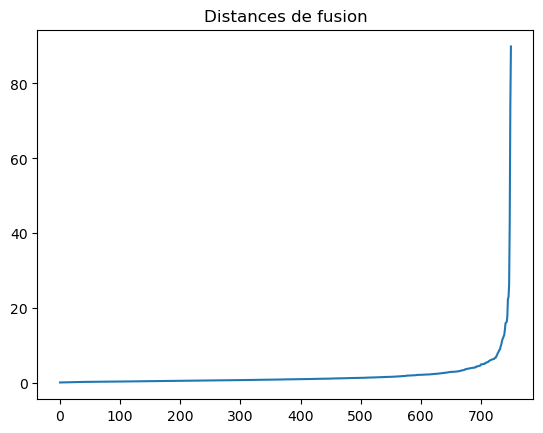

[ 1.66613864  0.18062286  0.14842665  1.43411219  4.63711747  0.59140532
  3.221162   16.78616713 30.69212589 16.19188259]


In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import  KMeans
from sklearn.preprocessing import StandardScaler

##### Programation de CAH #####
print("\n******* Classification Ascendante hiérarchique ******* \n")


# Garder seulement les premières composantes
r = 5  # ou 4 selon inertie expliquée
Xpca = U[:, :r] * D[:r]
# Calcul de l'arbre
M=linkage(Xpca,method='ward',metric='euclidean')


# On regarde si on retrouve bien le bon nombre de sujets, à savoir 4

print(np.round(M[:,2],2)) # Augmentation d’inertie (distance de fusion) à chaque étape
                          # On détermine le seuil en fonction de la taille du saut (grand saut = fusion de groupes très diff)

# Affichage de la courbe d'inértie en fonction des étapes pour mieux prendre une décision
plt.figure()
plt.plot(M[:,2])
plt.title("Distances de fusion")
plt.show()

print(np.diff(M[:,2])[-10:])




Classe par CAH 

Classe 1  : 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
Classe 2  : 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 37 37
Classe 3  : 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 1

C:\Users\malof\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(



Classe par k-mean 

Classe 1  : 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 10 10 10 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37 37
Classe 2  : Classe 3  : Classe 4  : 
******* Comparaison des inerties ******* 

Inertie Kmeans 4 centres:  3279.3291367558836
Inertie CAH 4 classes:  3463.2623758482223


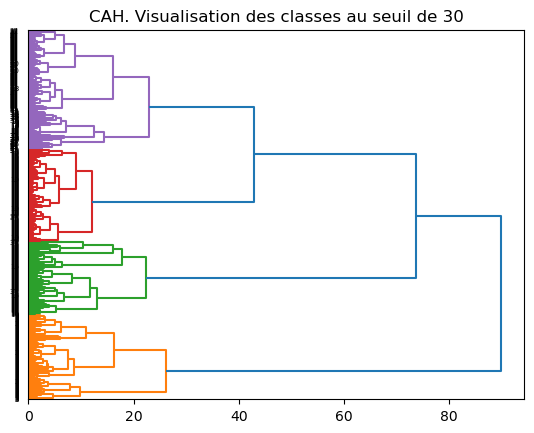

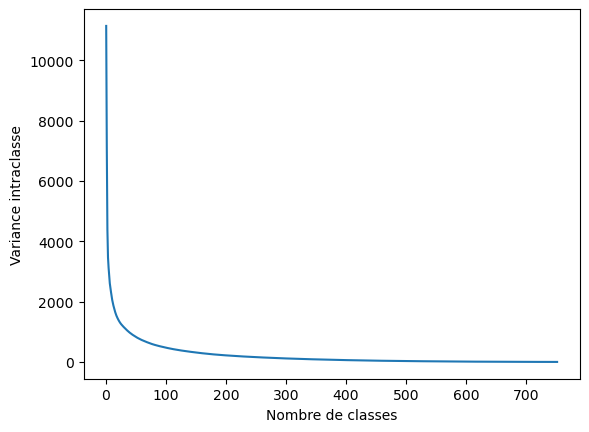

In [10]:
# Au regard des données, un seuil autour de 25 semble raisonnable, on règle l'affichage de l'arbre en conséquence
seuil = 30
plt.figure()
plt.title('CAH. Visualisation des classes au seuil de '+str(seuil))
d=dendrogram(M,labels=list(y),orientation='right',color_threshold=seuil)

##### Récupération des groupes
groupes=fcluster(M,t=seuil,criterion='distance')
print("\nClasse par CAH \n")
for k in range(1,np.max(groupes)+1):
    print('Classe '+str(k).ljust(3,' ')+': ', end='')
    print(*y[np.where(groupes==k)])

#### Décroissance des variances intraclasse
VI=np.cumsum(M[:,2]**2)/2
plt.figure()
plt.plot(np.arange(len(VI))+1,np.flip(VI,axis=0))
plt.xlabel("Nombre de classes")
plt.ylabel("Variance intraclasse")


# Comparaison avec les Kmeans
nclus=4 # Le nombre de sujets comparés
k_means = KMeans(init='k-means++', n_clusters=nclus, n_init=10)
k_means.fit(Xpca)
print("\nClasse par k-mean \n")
for k in range(nclus):
    print('Classe '+str(k+1).ljust(3,' ')+': ', end='')
    if (k%20 == 0):
        print(*y[np.where(k_means.labels_==k)])

print("\n******* Comparaison des inerties ******* \n")

print("Inertie Kmeans",nclus,"centres: ",k_means.inertia_)
print("Inertie CAH",nclus,"classes: ",VI[-nclus])



===== Analyse : K-means =====
Classe 0 → Sujet majoritaire : 37 (149 individus), taux d'erreur : 0.207
Classe 1 → Sujet majoritaire : 16 (148 individus), taux d'erreur : 0.213
Classe 2 → Sujet majoritaire : 3 (163 individus), taux d'erreur : 0.133
Classe 3 → Sujet majoritaire : 10 (185 individus), taux d'erreur : 0.016
Taux de mal classés : 0.142

===== Analyse : CAH =====
Classe 1 → Sujet majoritaire : 3 (174 individus), taux d'erreur : 0.074
Classe 2 → Sujet majoritaire : 16 (145 individus), taux d'erreur : 0.229
Classe 3 → Sujet majoritaire : 10 (184 individus), taux d'erreur : 0.021
Classe 4 → Sujet majoritaire : 37 (182 individus), taux d'erreur : 0.032
Taux de mal classés : 0.089


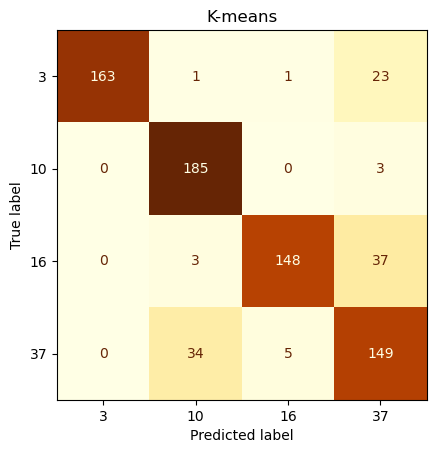

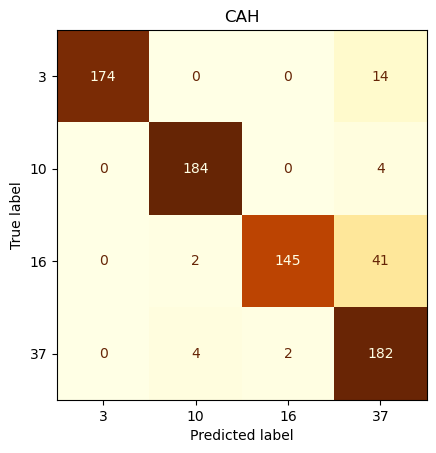

In [12]:
labels_pred_km = k_means.labels_
labels_pred_cah = groupes


from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import pandas as pd

def analyse_clustering(y_true, y_pred, nom="Clustering"):
    print("\n===== Analyse :", nom, "=====")

    
    # Sujet majoritaire par classe
    maj = {}
    for k in np.unique(y_pred):
        sujets, counts = np.unique(y_true[y_pred == k], return_counts=True)
        imax = np.argmax(counts)
        maj[k] = sujets[imax]
        print(f"Classe {k} → Sujet majoritaire : {sujets[imax]} ({counts[imax]} individus), taux d'erreur : {round((188-counts[imax])/188,3)}")

    # Remappage des classes vers le sujet majoritaire
    y_remap = np.array([maj[k] for k in y_pred])

    # Matrice de confusion
    cm =  confusion_matrix(y_true,y_remap)
    ConfusionMatrixDisplay(cm,display_labels=alea_slist).plot(cmap='YlOrBr',colorbar=False)
    plt.title(nom)

    # Taux d'erreur
    err = np.mean(y_true != y_remap)
    print("Taux de mal classés :", round(err, 3))

    return cm, err

cm_km, err_km = analyse_clustering(y, labels_pred_km, "K-means")
cm_cah, err_cah = analyse_clustering(y, labels_pred_cah, "CAH")

## Analyse discriminante

C:\Users\malof\AppData\Local\Temp\ipykernel_25612\2476679346.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,4))


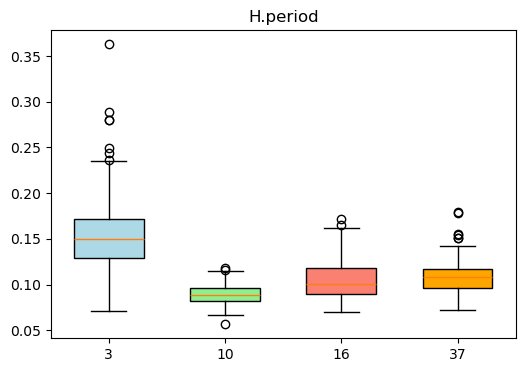

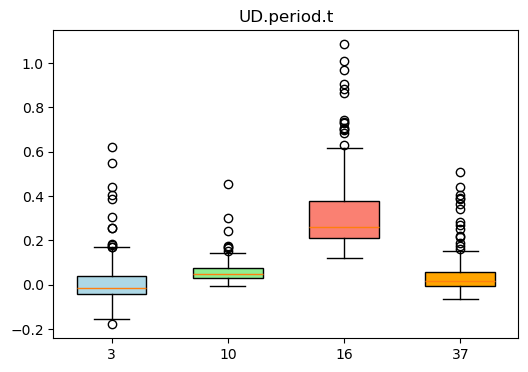

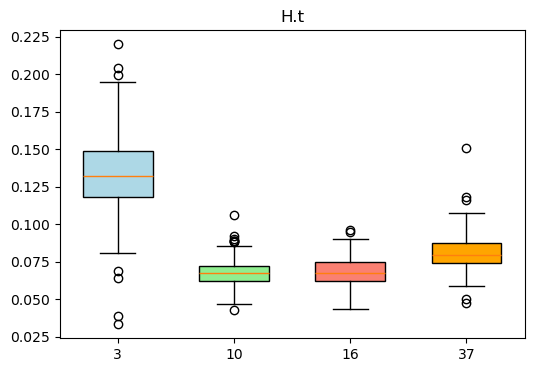

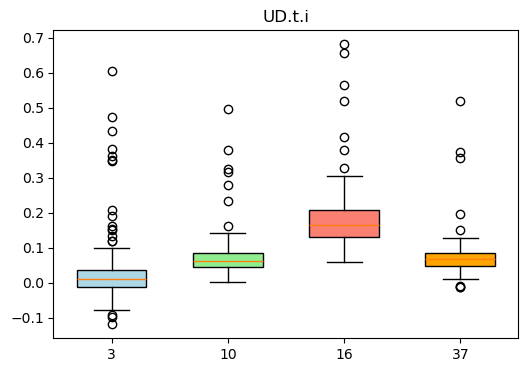

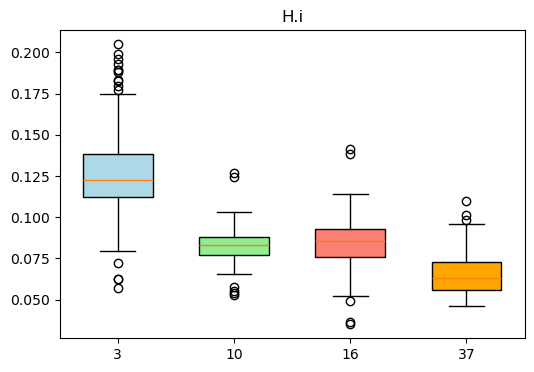

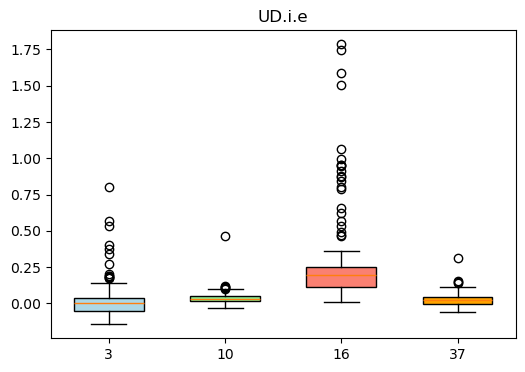

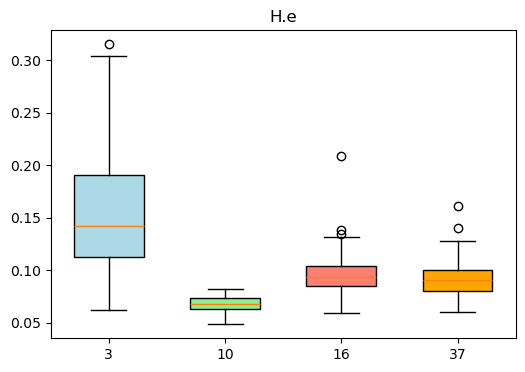

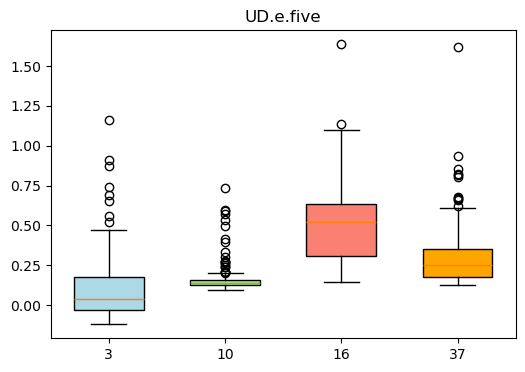

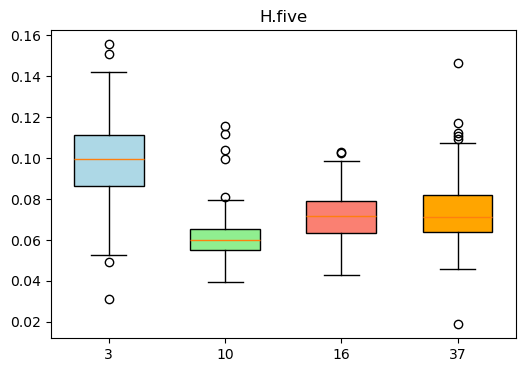

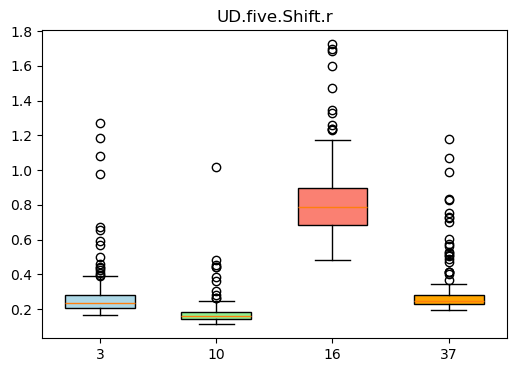

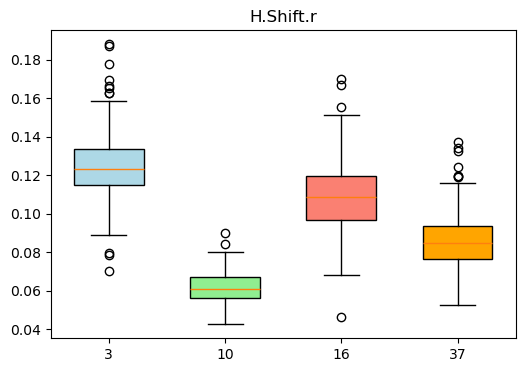

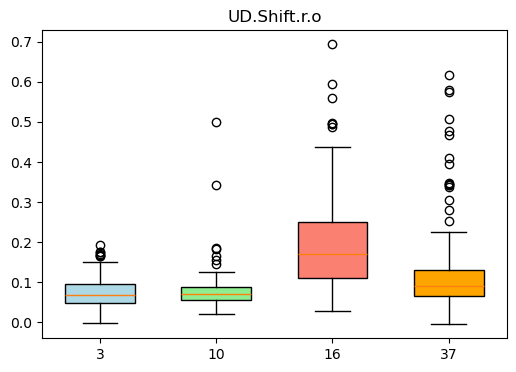

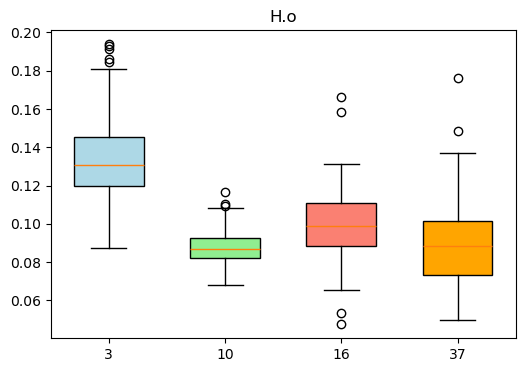

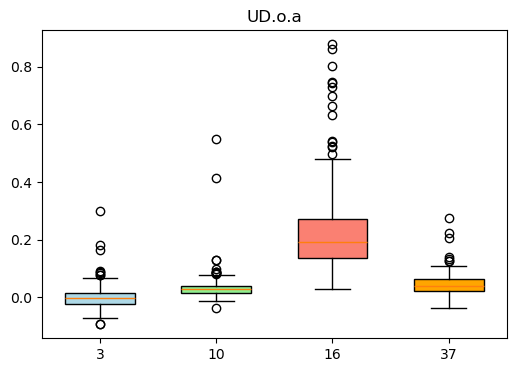

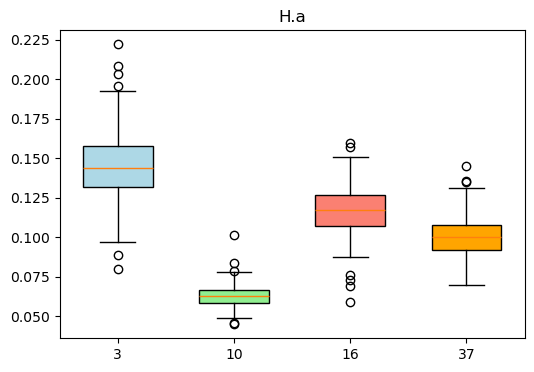

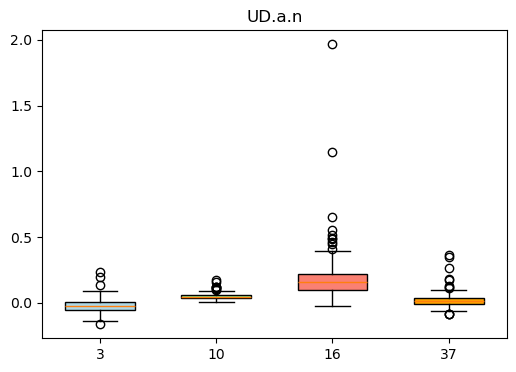

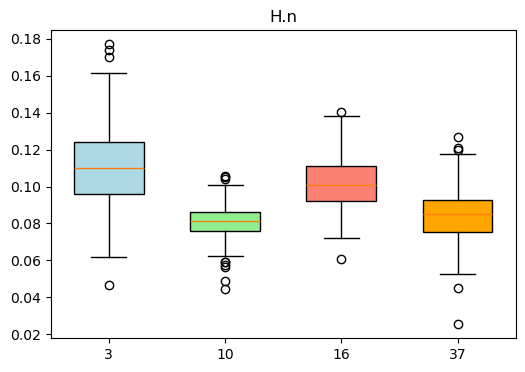

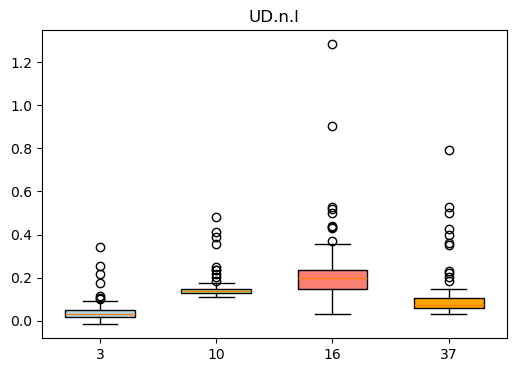

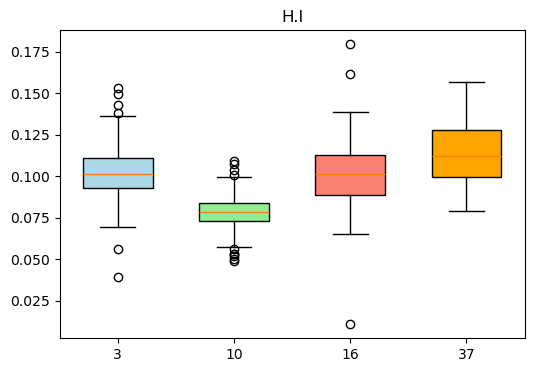

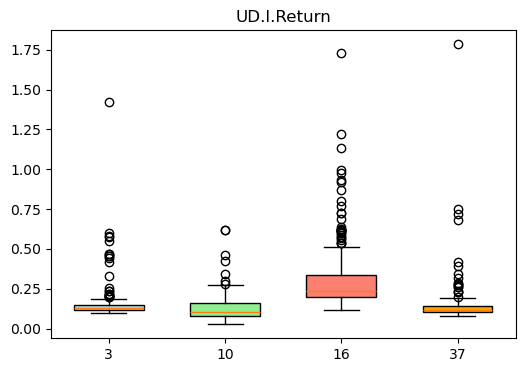

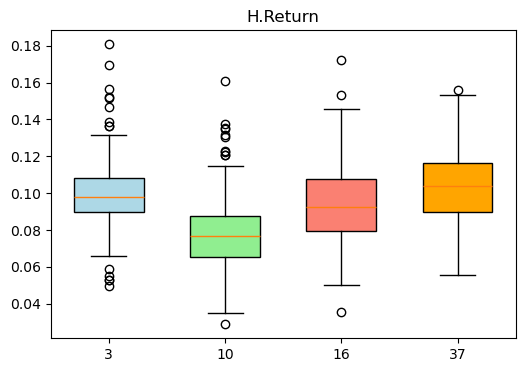

In [15]:
# Statistiques descriptives: boxplots -----------------------------------------
plt.close('all')
for j,nom in enumerate(nomvar):
    v = X[:,j]
    data = [v[y==alea_slist[0]],v[y==alea_slist[1]],v[y==alea_slist[2]],v[y==alea_slist[3]]]
    plt.figure(figsize=(6,4))
    v = X[:, j]
    data = [v[y == s] for s in alea_slist]
    box = plt.boxplot(data, tick_labels=alea_slist, widths=0.6, patch_artist=True)
    colors = ['lightblue','lightgreen','salmon','orange']

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        plt.title(nom)
        plt.grid()


Taux d'erreur:  0.015


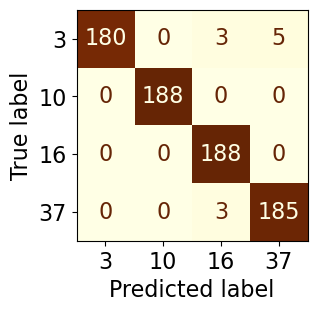

In [16]:
# Analyse discriminante linéaire ----------------------------------------------

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

lda = LinearDiscriminantAnalysis(n_components=2)

lda.fit(X,y)
yhat = lda.predict(X)
errl=sum(y!=yhat)/len(y) # Taux d'erreur d'apprentissage, forcément trop optimiste
print("Taux d'erreur: ",round(errl,3))
plt.rcParams.update({'figure.figsize': (3,3),'font.size': 16})
conf_mat =  confusion_matrix(y,yhat)
ConfusionMatrixDisplay(conf_mat,display_labels=alea_slist).plot(cmap='YlOrBr',colorbar=False)
plt.rcdefaults()

Classement des variables les plus discriminantes :
H.Shift.r  -> importance = 203.085
H.a  -> importance = 197.328
H.t  -> importance = 163.32
H.i  -> importance = 139.728
H.l  -> importance = 124.039
H.n  -> importance = 89.068
H.five  -> importance = 88.967
H.o  -> importance = 84.433
H.Return  -> importance = 64.076
H.e  -> importance = 49.921


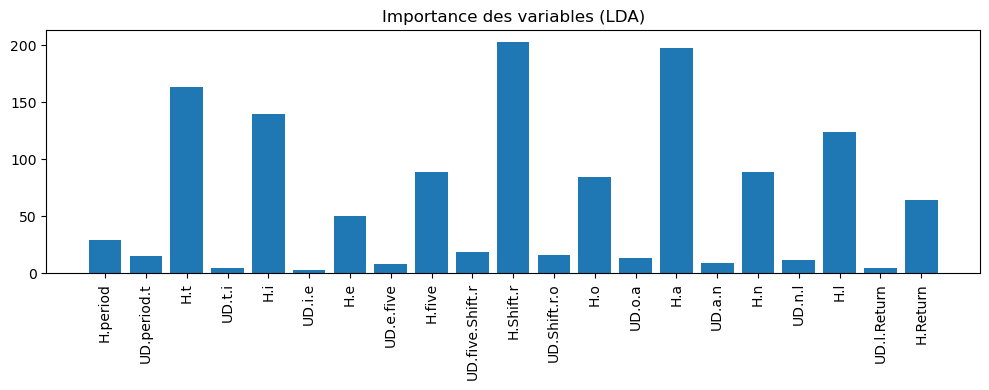

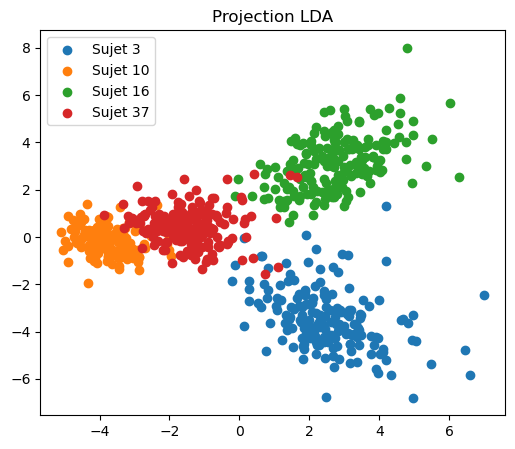

Pourcentage de variance expliquée par les deux premières composantes :  86.73455375015251


([<matplotlib.axis.XTick at 0x1a784203200>,
 [Text(1, 0, '1'), Text(2, 0, '2')])

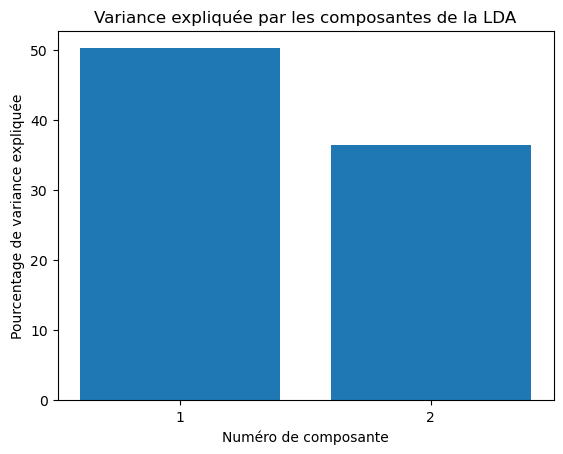

In [17]:
import pandas as pd


coef = lda.coef_   # matrice (nb_classes-1, nb_variables)

# Importance globale = norme des coefficients par variable
importance = np.linalg.norm(coef, axis=0)

# Trier
idx = np.argsort(importance)[::-1]

print("Classement des variables les plus discriminantes :")
for i in idx[:10]:
    print(nomvar[i], " -> importance =", round(importance[i],3))


plt.figure(figsize=(10,4))
plt.bar(range(len(importance)), importance)
plt.xticks(range(len(nomvar)), nomvar, rotation=90)
plt.title("Importance des variables (LDA)")
plt.tight_layout()
plt.show()

X_lda = lda.fit(X,y).transform(X)


plt.figure(figsize=(6,5))
for s in np.unique(y):
    plt.scatter(X_lda[y==s,0], X_lda[y==s,1], label=f"Sujet {s}")
plt.legend()
plt.title("Projection LDA")
plt.show()

exp_var = lda.explained_variance_ratio_ * 100
cum_exp_var = exp_var[1]+exp_var[0]
print("Pourcentage de variance expliquée par les deux premières composantes : ",cum_exp_var)

plt.bar(range(1, 3), exp_var, align='center')
plt.title("Variance expliquée par les composantes de la LDA")
plt.ylabel('Pourcentage de variance expliquée')
plt.xlabel('Numéro de composante')
plt.xticks(ticks=[1, 2])

Taux d'erreur (CV 5-fold) : 0.02


<Figure size 640x480 with 0 Axes>

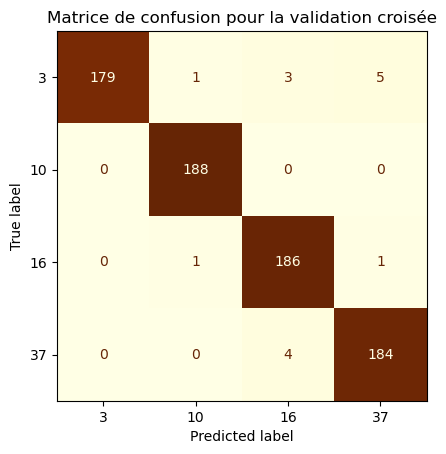

Sujet 3 : taux d'erreur = 0.048
Sujet 10 : taux d'erreur = 0.0
Sujet 16 : taux d'erreur = 0.011
Sujet 37 : taux d'erreur = 0.021


In [21]:
## -------- Validation croisée -------

from sklearn.model_selection import cross_val_predict

yhat_cv = cross_val_predict(lda, X, y, cv=5)
errl_cv = sum(y!=yhat_cv)/len(y)

print("Taux d'erreur (CV 5-fold) :", round(errl_cv,3))

conf_mat_cv = confusion_matrix(y, yhat_cv)

plt.figure()
ConfusionMatrixDisplay(conf_mat_cv,display_labels=alea_slist).plot(cmap='YlOrBr',colorbar=False)
plt.title("Matrice de confusion pour la validation croisée")
plt.show()


# Taux d'erreur par sujet
for s in np.unique(y):
    mask = (y == s)
    err_s = np.mean(yhat_cv[mask] != s)
    print(f"Sujet {s} : taux d'erreur = {round(err_s,3)}")

Taux d'erreur QDA (CV 5-fold) : 0.049


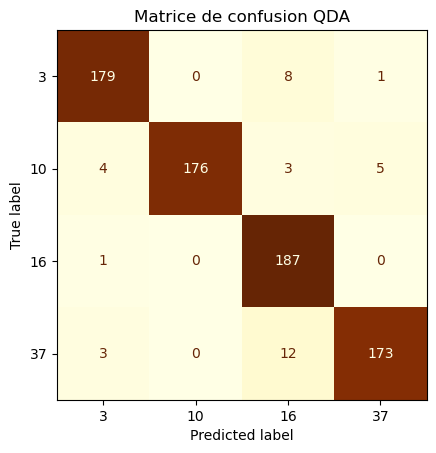

Sujet 3 : taux d'erreur = 0.048
Sujet 10 : taux d'erreur = 0.064
Sujet 16 : taux d'erreur = 0.005
Sujet 37 : taux d'erreur = 0.08


In [23]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

qda = QuadraticDiscriminantAnalysis()

yhat_qda = cross_val_predict(qda, X, y, cv=5)
err_qda = np.mean(y != yhat_qda)

print("Taux d'erreur QDA (CV 5-fold) :", round(err_qda,3))

conf_qda = confusion_matrix(y, yhat_qda)
ConfusionMatrixDisplay(conf_qda,display_labels=alea_slist).plot(cmap='YlOrBr',colorbar=False)
plt.title("Matrice de confusion QDA")
plt.show()

# Taux d'erreur par sujet
for s in np.unique(y):
    mask = (y == s)
    err_s = np.mean(yhat_qda[mask] != s)
    print(f"Sujet {s} : taux d'erreur = {round(err_s,3)}")